# Thư viện và file

In [164]:
# tính toán và xử lý
import numpy as np
import pandas as pd
# vẽ biểu đồ
import seaborn as sns
import matplotlib.pyplot as plt
# chia tập dữ liệu
from sklearn.model_selection import train_test_split
# mô hình
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
# phân tích kinh tế lượng
import statsmodels.api as sm

In [165]:
# Xem dữ liệu 5 dòng đầu
df = pd.read_csv("cleaned_data_1.csv")
df.head()

,title,price,area,district,city,bedroom,toilet,direction,legal_status,description,...,floors,living_size,source,listing_url,ad_id,list_id,ward,street,price_per_m2_source,image
0,8.9 tỷ nhà 76m đất Nguyễn Tri Phương Quận 10 r...,8900000000,76 m2,Quận 10,Tp Hồ Chí Minh,3,3,NaN,1.0,+ Nhà cũ nát thích hợp xây mới để ở hoặc xây c...,...,area_m2,area_m2,chotot_api,https://www.nhatot.com/mua-ban-nha-dat/89-tỷ-n...,176441544,132697643,Phường 4,Đường Nguyễn Tri Phương,117.105260,https://cdn.chotot.com/YYljDEih95e2TjgogP-2zqq...
1,SIÊU HIẾM–2 MẶT TIỀN HXH HIỆP PHÚ–DÒNG TIỀN 12...,6000000000,105 m2,Thành phố Thủ Đức,Tp Hồ Chí Minh,4,3,NaN,1.0,Dự án: \nThông tin chi tiết: 🔥🔥 SIÊU HIẾM – 2 ...,...,150.0,150.0,chotot_api,https://www.nhatot.com/mua-ban-nha-dat/siêu-hi...,175574550,131952985,Phường Hiệp Phú (Quận 9 cũ),Đường Lê Văn Việt,57.142857,https://cdn.chotot.com/z2WNGObdNhy12nSZQ53yVwP...
2,"BÁN NHÀ 5 X 20, TRỆT LẦU BTCT, GẦN ĐỒNG TÂM, T...",5300000000,100 m2,Huyện Hóc Môn,Tp Hồ Chí Minh,4,2,7.0,1.0,"NHÀ TRỆT LẦU ĐÚC BTCT. \nDT 5 X 20. 4PN, 2WC....",...,125.0,125.0,chotot_api,https://www.nhatot.com/mua-ban-nha-dat/bán-nhà...,175867044,132203013,Xã Trung Chánh,Đường Trung Chánh 2 Ấp Mỹ Hoà 1,53.000000,https://cdn.chotot.com/ot8OljyNdiP-2gymrKmRcL4...
3,🌇 Vinhome Grand Park Quận 9 The Origami,3950000000,69.3 m2,Thành phố Thủ Đức,Tp Hồ Chí Minh,2,2,6.0,6.0,Dự án: \nThông tin chi tiết: 🌇 Vinhome Grand P...,...,area_m2,area_m2,chotot_api,https://www.nhatot.com/mua-ban-nha-dat/🌇-vinho...,176441426,132697554,Phường Long Thạnh Mỹ (Quận 9 cũ),Nguyễn Xiển,56.998558,https://cdn.chotot.com/taNFXR_3J2SSoDnfhL49ChZ...
4,Cần Bán gấp nhà P TTN Q12.DT 4x18 .1 trệt 2Lầu...,5200000000,72 m2,Quận 12,Tp Hồ Chí Minh,3,4,NaN,1.0,"BÁN NHÀ TÂN THỚI NHẤT, QUẬN 12 – SHR\nDT: 4M x...",...,216.0,216.0,chotot_api,https://www.nhatot.com/mua-ban-nha-dat/cần-bán...,173351952,130041561,Phường Tân Thới Nhất,Tân THỚI Nhất,72.222220,https://cdn.chotot.com/9fu0at8loUQ3PL_WxUtlERo...


In [166]:
# xem thông tin số cột, số dòng
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14741 entries, 0 to 14740
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                14741 non-null  str    
 1   price                14741 non-null  int64  
 2   area                 14741 non-null  str    
 3   district             14740 non-null  str    
 4   city                 14741 non-null  str    
 5   bedroom              14741 non-null  int64  
 6   toilet               14741 non-null  int64  
 7   direction            3698 non-null   float64
 8   legal_status         11549 non-null  float64
 9   description          14741 non-null  str    
 10  publish_date         14741 non-null  str    
 11  latitude             14707 non-null  float64
 12  longitude            14707 non-null  float64
 13  price_vnd            14741 non-null  float64
 14  area_m2              14741 non-null  float64
 15  price_per_m2         14741 non-null  float64
 1

In [167]:
# Số lượng dữ liệu bị thiếu 
print(df.isnull().sum())
print(f"Dữ liệu trùng lặp: {df.duplicated().sum()}")

title                      0
price                      0
area                       0
district                   1
city                       0
bedroom                    0
toilet                     0
direction              11043
legal_status            3192
description                0
publish_date               0
latitude                  34
longitude                 34
price_vnd                  0
area_m2                    0
price_per_m2               0
price_billion              0
district_norm              0
city_norm                  0
direction_norm             0
legal_status_norm          0
category                   0
house_type                 0
floors                     0
living_size                0
source                     0
listing_url                0
ad_id                      0
list_id                    0
ward                      36
street                     0
price_per_m2_source        0
image                     10
dtype: int64
Dữ liệu trùng lặp: 0


In [168]:
# thống kê mô tả dữ liệu
df.describe()


,price,bedroom,toilet,direction,legal_status,latitude,longitude,price_vnd,area_m2,price_per_m2,price_billion,ad_id,list_id,price_per_m2_source
count,1.474100e+04,14741.000000,14741.000000,3698.000000,11549.000000,14707.000000,14707.000000,1.474100e+04,14741.000000,1.474100e+04,14741.000000,1.474100e+04,1.474100e+04,14741.000000
mean,8.705484e+09,3.338783,3.012618,4.696052,1.999221,14.244982,106.378035,8.705484e+09,84.318929,1.289236e+08,8.705484,1.753611e+08,1.317703e+08,128.923572
std,1.242770e+10,1.737997,1.268062,2.255181,1.909699,4.828333,0.410148,1.242770e+10,157.404785,1.048890e+08,12.427704,2.590666e+06,2.215993e+06,104.888996
min,2.100000e+08,1.000000,1.000000,1.000000,1.000000,10.249397,104.026660,2.100000e+08,10.000000,5.000000e+06,0.210000,9.305420e+07,6.434092e+07,5.000000
25%,3.860000e+09,2.000000,2.000000,3.000000,1.000000,10.785433,105.851780,3.860000e+09,42.000000,6.250000e+07,3.860000,1.753146e+08,1.317300e+08,62.500000
50%,6.000000e+09,3.000000,3.000000,5.000000,1.000000,10.842642,106.625175,6.000000e+09,60.000000,1.014062e+08,6.000000,1.760297e+08,1.323437e+08,101.406250
75%,8.980000e+09,4.000000,3.000000,6.000000,1.000000,20.987461,106.679980,8.980000e+09,83.000000,1.690909e+08,8.980000,1.763379e+08,1.326100e+08,169.090910
max,2.990000e+11,11.000000,7.000000,8.000000,6.000000,22.418290,107.114650,2.990000e+11,5000.000000,1.600000e+09,299.000000,1.764415e+08,1.326976e+08,1600.000000


In [169]:
# Danh sách các cột cần loại bỏ dựa trên phân tích dữ liệu
cols_to_drop = [
    # Cột định danh, không liên quan, chủ yếu liên quan đến nguồn
    'ad_id', 'list_id', 'listing_url', 'source', 'image', 
    # Cột trùng lặp
    'city', 'district', 'direction', 'legal_status', 
    # Nhóm chữ không liên quan (nhiễu text)
    'title', 'description', 
    # Nhóm dữ liệu số trùng lặp (không cần thiết)
    'price', 'area', 'price_vnd', 'price_per_m2_source'
]
# Xoá trên bảng dữ liệu hiện tại
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
# In ra thông tin các cột còn lại
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14741 entries, 0 to 14740
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bedroom            14741 non-null  int64  
 1   toilet             14741 non-null  int64  
 2   publish_date       14741 non-null  str    
 3   latitude           14707 non-null  float64
 4   longitude          14707 non-null  float64
 5   area_m2            14741 non-null  float64
 6   price_per_m2       14741 non-null  float64
 7   price_billion      14741 non-null  float64
 8   district_norm      14741 non-null  str    
 9   city_norm          14741 non-null  str    
 10  direction_norm     14741 non-null  str    
 11  legal_status_norm  14741 non-null  str    
 12  category           14741 non-null  str    
 13  house_type         14741 non-null  str    
 14  floors             14741 non-null  str    
 15  living_size        14741 non-null  str    
 16  ward               14705 non-null

In [170]:
# In ra số lượng đơn vị 
print(df.value_counts())
# loại bỏ dữ liệu hà nội đi vì số lượng không đảm bảo
print(f"Số lượng dữ liệu ở hai thành phố: {df['city_norm'].value_counts()}")
df_clean = df[df['city_norm']=='Ho_Chi_Minh'].copy()
# in ra kích thước dữ liệu còn lại
print(df_clean.shape)

bedroom  toilet  publish_date  latitude   longitude  area_m2  price_per_m2  price_billion  district_norm  city_norm    direction_norm  legal_status_norm  category                        house_type  floors   living_size  ward                    street           
2        2       2026-05-30    10.800204  106.60945  44.0     76136364.0    3.35           Binh_Tan       Ho_Chi_Minh  Unknown         1_0                Nhà ở                           3.0         88.0     88.0         Phường Bình Hưng Hòa    Đường số 13          2
                               10.732890  106.64306  65.0     42615385.0    2.77           District_8     Ho_Chi_Minh  Unknown         6_0                Căn hộ/Chung cư                 Unknown     area_m2  area_m2      Phường 6                Phạm Thế Hiển        2
                               10.829540  106.61561  58.0     41379310.0    2.40           District_12    Ho_Chi_Minh  Unknown         Unknown            Căn hộ/Chung cư                 Unknown     area_m

In [171]:
df_clean = df_clean.drop(
    columns=['floors', 'living_size'],
    errors='ignore'
)

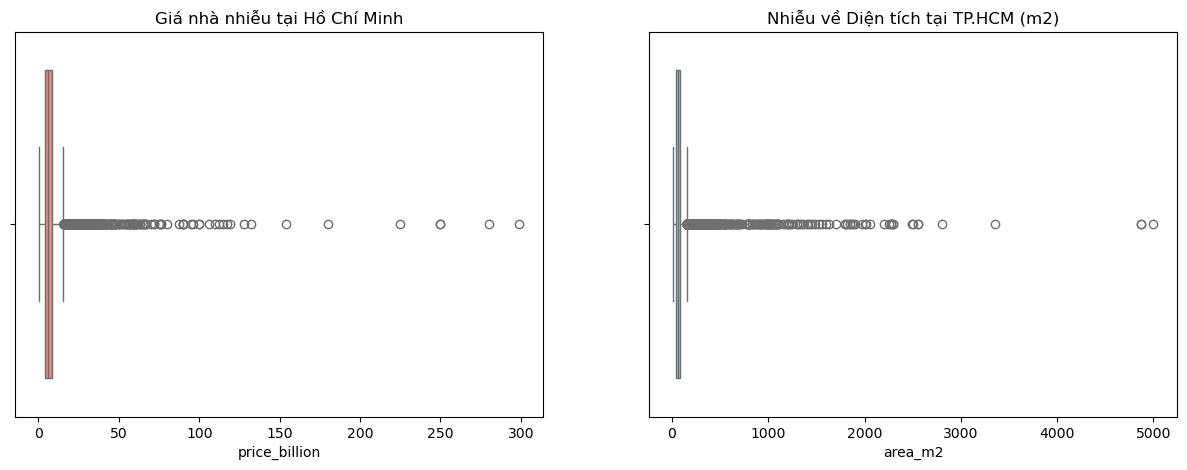

In [172]:
# Biểu đồ minh hoạ số lượng dữ liệu ngoại lai
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(ax=axes[0], x= df_clean['price_billion'], color='salmon')
axes[0].set_title("Giá nhà nhiễu tại Hồ Chí Minh")
sns.boxplot(ax=axes[1], x=df_clean['area_m2'], color='skyblue')
axes[1].set_title('Nhiễu về Diện tích tại TP.HCM (m2)')
plt.show()

In [173]:
# Loại bỏ giá nhà nằm ngoài (0-150) tỷ đồng và diện tích (0-2000)
df_clean = df_clean[
    (df_clean['price_billion'] > 0.1) & (df_clean['price_billion'] <= 150)
    & (df_clean['area_m2'] > 10) & (df_clean['area_m2'] <= 1500)  
]
print(len(df_clean))

9712


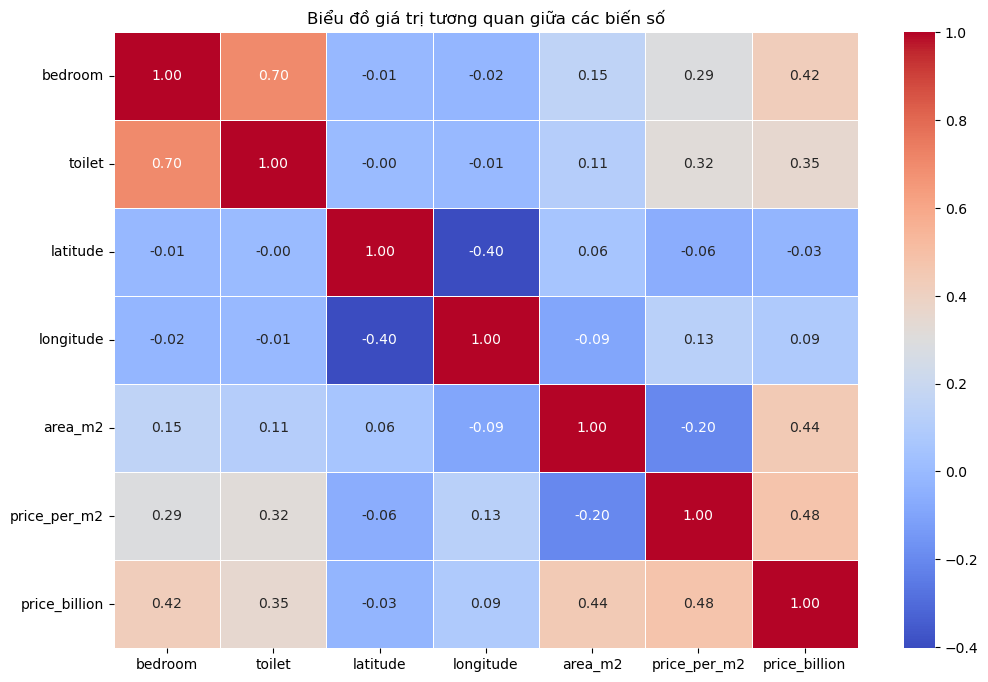

In [174]:
# Tính ma trận tương quan
    # chỉ chọn giá trị int và float
numeric_col = df_clean.select_dtypes(include=['int64', 'float64']).columns
    # tính ma trận tương quan bằng correclation matrix 
correclation_matrix = df_clean[numeric_col].corr()
    # Vẽ dưới dạng biểu đồ heap với kích thước 10*8 hoặc 12*8 
plt.figure(figsize=(12,8))
sns.heatmap(correclation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)  
plt.title("Biểu đồ giá trị tương quan giữa các biến số")
plt.show() 

# Dựa vào ma trận tương quan, ta thấy
Vấn đề 1: 
- Hệ số tương quan giữa 'price_billion' và latitude là -0.03 (gần bằng 0)
--> Không có mối quan hệ tuyến tính
- Hệ số tương quan giữa 'price_billion' và longitude là 0.09 (Hệ số tương quan yếu)
--> Không có mối quan hệ tuyến tính
- Tuy nhiên, trong bất động sản thì vị trí sẽ có yếu tố tác động mạnh đến giá nhà vì vậy hướng giải pháp là xây dựng hàm tính khoảng cách giữa vị trí hiện tại đến một vị trí mốc với là khu vực Uỷ ban nhân dân quận 1 với mốc toạ độ 
(Vĩ độ(Latitude): 10.7765, Kinh độ (Longtitude)106.7009)
Vấn đề 2:
- Hệ số tương quan giữa 'bedroom' và 'toilet' là 0.7
--> Xảy ra hiện tượng đa cộng tuyến --> Loại bỏ cột toilet vì tương quan bedroom với pricebillion tốt hơn

In [175]:
# Loại bỏ cột toilet và tính toán khoảng cách bằng công thức Haversine
# Hàm tính khoảng cách 
def Haversine_distance(latitude_center, longitude_center, latitude , longitude):
    # Bán kinh trái đất
    R = 6371.0
    # Chuyển đổi toạ độ từ Degree sang Radian 
    lat_1 = np.radians(latitude_center)
    lat_2 = np.radians(latitude)
    lon_1 = np.radians(longitude_center)
    lon_2 = np.radians(longitude)
    # Tính độ chênh lệch
    distance_lat = lat_2 - lat_1
    distance_lon = lon_2 - lon_1
    a = np.sin(distance_lat / 2)**2 + np.cos(lat_1) * np.cos(lat_2) * np.sin(distance_lon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R*c
# Loại bỏ cột toilet 
df_clean = df_clean.drop(columns=['toilet'])
# Tính toán khoảng cách với vị trí tâm là uỷ ban nhân dân quận 1 với lat = 10.7765 và lon = 106.7009
lat_center = 10.7765
lon_center = 106.7009
df_clean['Distance_to_center'] = Haversine_distance(lat_center, 
                                                    lon_center, df_clean['latitude'], df_clean['longitude'])
print(df_clean[[ 'longitude' ,'latitude', 'Distance_to_center']].head())

    longitude   latitude  Distance_to_center
0  106.668846  10.760203            3.942615
1  106.775010  10.848368           11.374550
2  106.608770  10.860773           13.749931
3  106.819720  10.845400           15.070376
4  106.613205  10.835916           11.635901


In [176]:
# Kiếm tra ma trận tương quan giữa cột distance_to_center và cột price_billion
cor_distace_price = df_clean[['Distance_to_center', 'price_billion']].corr()
print(cor_distace_price)

                    Distance_to_center  price_billion
Distance_to_center             1.00000       -0.05886
price_billion                 -0.05886        1.00000


# Dựa vào kết quả tương quan hiện tại thì: 
- Mô hình Linear Regression sẽ không đưa vào vì hệ số tương quan quá thấp 
- Decision Tree và Random Forest thì đưa vào
(Giải thích: Mô hình hồi quy tuyến tính là mô hình có dạng đường thẳng, khi hệ số tương quan quá lệch chỉ có ra kết quả sai còn với 2 mô hình còn lại thì sẽ đưa vào lí do nó không ảnh hưởng quá nhiều bởi mối quan hệ tuyến tính)

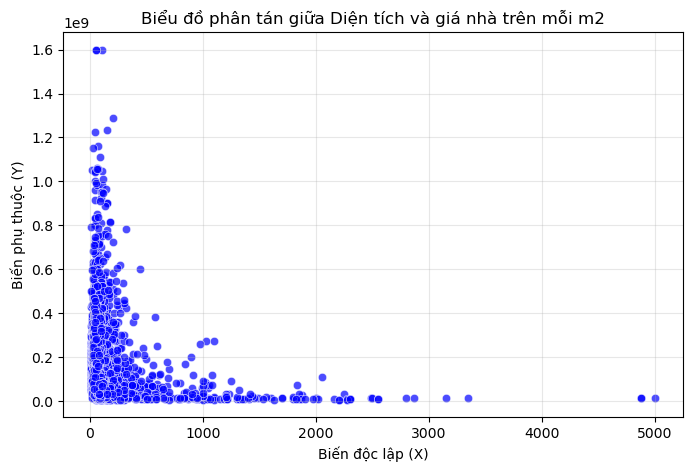

In [177]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='area_m2', y='price_per_m2', color='blue', alpha=0.7)
plt.title('Biểu đồ phân tán giữa Diện tích và giá nhà trên mỗi m2')
plt.xlabel('Biến độc lập (X)')
plt.ylabel('Biến phụ thuộc (Y)')
plt.grid(True, alpha=0.3)
plt.show()

In [178]:
df_clean.value_counts

<bound method DataFrame.value_counts of       bedroom publish_date   latitude   longitude  area_m2  price_per_m2  \
0           3   2026-05-30  10.760203  106.668846     76.0   117105263.0   
1           4   2026-05-30  10.848368  106.775010    105.0    57142857.0   
2           4   2026-05-30  10.860773  106.608770    100.0    53000000.0   
3           2   2026-05-30  10.845400  106.819720     69.3    56998557.0   
4           3   2026-05-30  10.835916  106.613205     72.0    72222222.0   
...       ...          ...        ...         ...      ...           ...   
9767        2   2026-05-27  10.737508  106.656235     38.5   140000000.0   
9768        6   2026-05-27  10.852403  106.626600    120.0    95833333.0   
9769        4   2026-05-27  10.826139  106.692740     60.0   113333333.0   
9770        6   2026-05-27  10.795761  106.620180     48.0   145833333.0   
9771        2   2026-05-27  10.756644  106.714966     25.0   220000000.0   

      price_billion district_norm    city_norm 

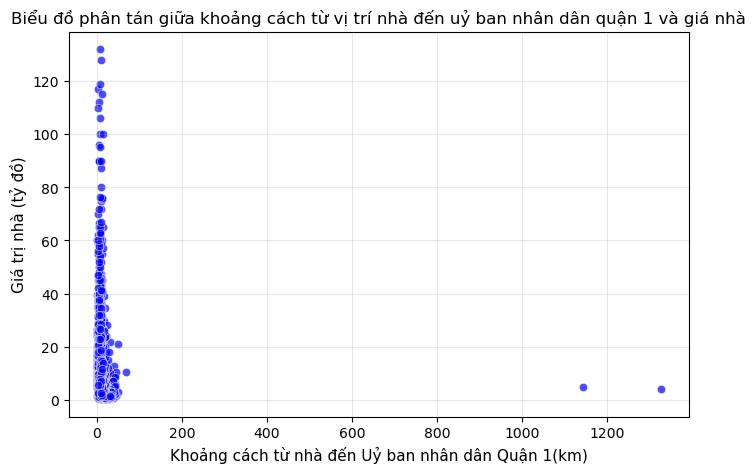

In [179]:
# Biểu đồ phân tán giá nhà và khoảng cách
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x= 'Distance_to_center' , y='price_billion', color='blue', alpha=0.7)
plt.title('Biểu đồ phân tán giữa khoảng cách từ vị trí nhà đến uỷ ban nhân dân quận 1 và giá nhà')
plt.xlabel('Khoảng cách từ nhà đến Uỷ ban nhân dân Quận 1(km)', fontsize= 11)
plt.ylabel('Giá trị nhà (tỷ đồ)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Dựa vào biểu đồ phân tán giữa giá nhà và khoảng cách thì có 2 giá trị nhiễu --> Loại bỏ

In [180]:
# Loại bỏ giá trị nằm ngoài khoảng cách 60km theo đường chim bay
df_clean = df_clean[df_clean['Distance_to_center'] <= 60]

C:\Users\HOME\AppData\Local\Temp\ipykernel_2000\70645179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='district_norm', y='price_billion', order=order, palette='Set3')


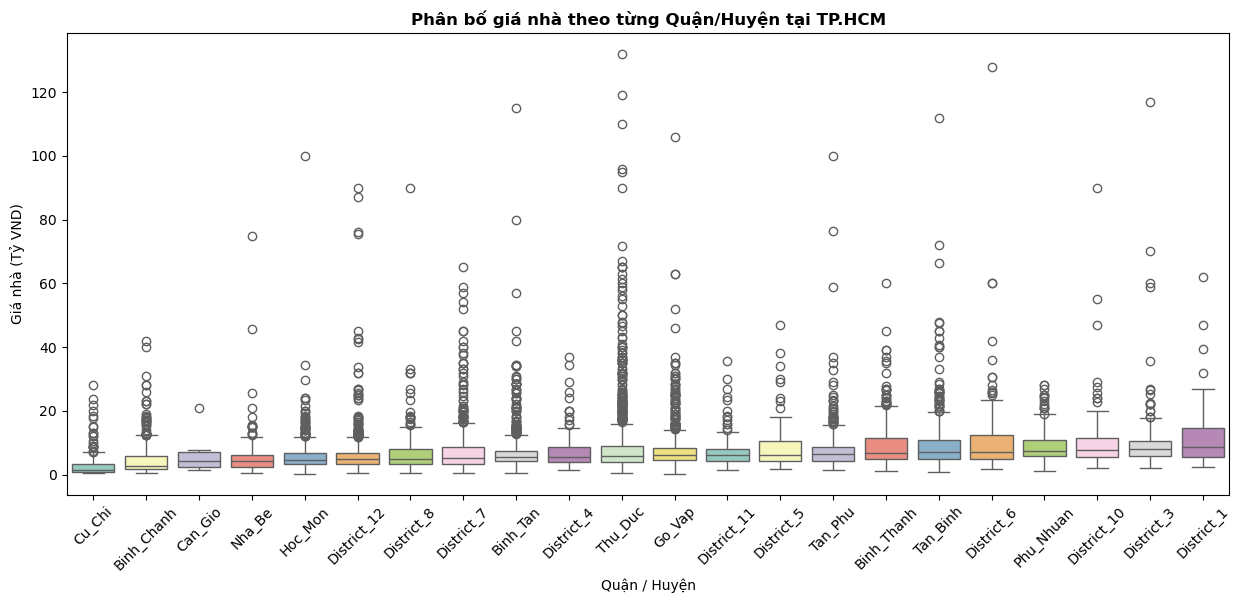

In [181]:
plt.figure(figsize=(15, 6))
# Sắp xếp các quận theo giá trung vị tăng dần 
order = df_clean.groupby('district_norm')['price_billion'].median().sort_values().index
sns.boxplot(data=df_clean, x='district_norm', y='price_billion', order=order, palette='Set3')
plt.title('Phân bố giá nhà theo từng Quận/Huyện tại TP.HCM', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Quận / Huyện')
plt.ylabel('Giá nhà (Tỷ VND)')
plt.show()

# Chia tập dữ liệu thành 2 nhóm với một tập cho Linear Resgression và một tập cho Random Forest 
- Lý do chia: mô hình Linear Regsion là một mô hình hồi quy tuyến tính, khi các giá trị ngoại lại càng ở phía xa thì sẽ gây ra hiện tượng nhiễu cao. Tuy nhiên với mô hình Random Forest thì là mô hình ngẫu nhiên, các giá trị ngoại lại sẽ không bị nhiễu nhiều mà sẽ dưới dạng điều kiện, nhiễu thấp, thế nên chia mô hình ra để cho có sự cân bằng ở mô hình

In [182]:
# Hàm xử lí dữ liệu nhiễu
def remove_outliers_iqr_by_district(df, target_col, group_col):
    df_filtered = pd.DataFrame()
    
    # Duyệt qua từng quận để tính toán độc lập
    for district, group in df.groupby(group_col):
        Q1 = group[target_col].quantile(0.25)
        Q3 = group[target_col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Xác định biên an toàn của từng quận
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Chỉ giữ lại các dòng nằm trong khoảng an toàn
        group_clean = group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]
        df_filtered = pd.concat([df_filtered, group_clean], axis=0)
        
    return df_filtered

In [183]:
# lọc sạch nhiễu để đưa vào
df_clean = df_clean[df_clean['Distance_to_center'] <= 60].copy()
# Nhánh Linear Regression: Sử dụng hàm IQR vừa định nghĩa ở trên để dọn sạch chấm tròn
df_for_linear = remove_outliers_iqr_by_district(df_clean, 'price_billion', 'district_norm')

# Nhánh Random Forest: Giữ nguyên các chấm tròn (Không cần lọc IQR)
df_for_random = df_clean.copy()
# 4. In kiểm tra số lượng dòng để chắc chắn dữ liệu tập Linear ĐÃ GIẢM
print("--- KIỂM TRA SỐ DÒNG ---")
print(f"Số dòng ban đầu: {len(df_clean)}")
print(f"Số dòng tập LINEAR: {len(df_for_linear)}")
print(f"Số dòng tập RANDOM FOREST: {len(df_for_random)}")

--- KIỂM TRA SỐ DÒNG ---
Số dòng ban đầu: 9683
Số dòng tập LINEAR: 8950
Số dòng tập RANDOM FOREST: 9683


In [184]:
# xem lại bảng dữ liệu
df_for_linear.info()
df_for_random.info()

<class 'pandas.DataFrame'>
Index: 8950 entries, 119 to 9761
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bedroom             8950 non-null   int64  
 1   publish_date        8950 non-null   str    
 2   latitude            8950 non-null   float64
 3   longitude           8950 non-null   float64
 4   area_m2             8950 non-null   float64
 5   price_per_m2        8950 non-null   float64
 6   price_billion       8950 non-null   float64
 7   district_norm       8950 non-null   str    
 8   city_norm           8950 non-null   str    
 9   direction_norm      8950 non-null   str    
 10  legal_status_norm   8950 non-null   str    
 11  category            8950 non-null   str    
 12  house_type          8950 non-null   str    
 13  ward                8948 non-null   str    
 14  street              8950 non-null   str    
 15  Distance_to_center  8950 non-null   float64
dtypes: float64(6), int64

# Dựa vào bảng dữ liệu trên thì thấy có nhiều dữ liệu còn ở dạng str vì vậy cần chuyển sang dữ liệu int để mô hình học 

In [185]:
# Loại bỏ các cột dữ liệu không cần thiết để tiến hàng chia dữ liệu train
col = ['direction_norm', 'city_norm', 'ward', 'street', 'publish_date']
df_for_linear = df_for_linear.drop(columns=col, errors='ignore')
df_for_random = df_for_random.drop(columns=col, errors='ignore')

In [186]:

# các cột dữ liệu cần chuyển
categorical_col = ['district_norm', 'house_type', 'category', 'legal_status_norm']
# chuyển sang kiểu dữ liệu số
df_linear_encoded = pd.get_dummies(df_for_linear, columns=categorical_col, drop_first=True, dtype=int)
df_random_encoded = pd.get_dummies(df_for_random, columns=categorical_col, drop_first=True, dtype=int)

In [187]:
# Danh sách các cột chữ cần chuyển đổi thành số
categorical_cols = ['district_norm', 'house_type', 'category', 'legal_status_norm']

# Ép kiểu dữ liệu về string để tránh lỗi bỏ sót của Pandas
for col in categorical_cols:
    df_for_linear[col] = df_for_linear[col].astype(str)
    df_for_random[col] = df_for_random[col].astype(str)

# Tiến hành mã hóa thành các cột số nhị phân 0 và 1
df_linear_encoded = pd.get_dummies(df_for_linear, columns=categorical_cols, drop_first=True, dtype=int)
df_random_encoded = pd.get_dummies(df_for_random, columns=categorical_cols, drop_first=True, dtype=int)
print("--- KIỂM TRA SỐ CỘT SAU MÃ HÓA ---")
print(f"Số lượng cột ma trận Linear: {df_linear_encoded.shape[1]}")
print(f"Số lượng cột ma trận Random Forest: {df_random_encoded.shape[1]}")

--- KIỂM TRA SỐ CỘT SAU MÃ HÓA ---
Số lượng cột ma trận Linear: 41
Số lượng cột ma trận Random Forest: 41


# Chia dữ liệu theo phương pháp 80/20

In [188]:
# Tách biến độc lập (X) và biến mục tiêu (y) - Loại bỏ price_per_m2 để tránh rò rỉ đáp án
X_linear = df_linear_encoded.drop(columns=['price_billion', 'price_per_m2'], errors='ignore')
y_linear = df_linear_encoded['price_billion']

X_random = df_random_encoded.drop(columns=['price_billion', 'price_per_m2'], errors='ignore')
y_random = df_random_encoded['price_billion']

# Thực hiện chia tập dữ liệu
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_random, y_random, test_size=0.2, random_state=42
)

print("Chia dữ liệu hoàn tất thành công!")
print(f"Nhánh LINEAR       -> Tập Train: {X_train_lr.shape[0]} dòng | Tập Test: {X_test_lr.shape[0]} dòng")
print(f"Nhánh RANDOM FOREST -> Tập Train: {X_train_rf.shape[0]} dòng | Tập Test: {X_test_rf.shape[0]} dòng")

Chia dữ liệu hoàn tất thành công!
Nhánh LINEAR       -> Tập Train: 7160 dòng | Tập Test: 1790 dòng
Nhánh RANDOM FOREST -> Tập Train: 7746 dòng | Tập Test: 1937 dòng


In [189]:
for col in X_train_lr.columns:
    if X_train_lr[col].astype(str).str.contains('area_m2', na=False).any():
        print("Lỗi ở cột:", col)

In [190]:
# Huấn luyện mô hình
# 1. Khởi tạo mô hình
lr_model = LinearRegression()
# Cố định random_state để kết quả của Random Forest không bị thay đổi sau mỗi lần chạy
rf_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
    ) 

# 2. Tiến hành huấn luyện mô hình Linear Regression
print("Đang huấn luyện mô hình Linear Regression...")
lr_model.fit(X_train_lr, y_train_lr)

# 3. Tiến hành huấn luyện mô hình Random Forest
print("Đang huấn luyện mô hình Random Forest...")
rf_model.fit(X_train_rf, y_train_rf)

print("Huấn luyện thành công cả 2 mô hình!")

Đang huấn luyện mô hình Linear Regression...
Đang huấn luyện mô hình Random Forest...
Huấn luyện thành công cả 2 mô hình!


In [191]:
# 1. Thực hiện dự báo trên tập Test độc lập
y_pred_lr = lr_model.predict(X_test_lr)
y_pred_rf = rf_model.predict(X_test_rf)

# 2. Tính toán các chỉ số chấm điểm cho Linear Regression
r2_lr = r2_score(y_test_lr, y_pred_lr)
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

# 3. Tính toán các chỉ số chấm điểm cho Random Forest
r2_rf = r2_score(y_test_rf, y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

# 4. Tạo bảng tổng hợp kết quả
evaluation_results = pd.DataFrame({
    'Chỉ số đánh giá': ['Hệ số xác định R2 Score (%)', 'Sai số trung bình MAE (Tỷ)', 'Sai số phạt RMSE (Tỷ)'],
    'Linear Regression (Đã lọc nhiễu)': [f"{r2_lr*100:.2f}%", f"{mae_lr:.3f} Tỷ", f"{rmse_lr:.3f} Tỷ"],
    'Random Forest (Giữ nguyên nhiễu)': [f"{r2_rf*100:.2f}%", f"{mae_rf:.3f} Tỷ", f"{rmse_rf:.3f} Tỷ"]
})

print("BẢNG KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH Lần thứ 1")
display(evaluation_results)

BẢNG KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH Lần thứ 1


,Chỉ số đánh giá,Linear Regression (Đã lọc nhiễu),Random Forest (Giữ nguyên nhiễu)
0,Hệ số xác định R2 Score (%),54.30%,68.64%
1,Sai số trung bình MAE (Tỷ),1.647 Tỷ,1.810 Tỷ
2,Sai số phạt RMSE (Tỷ),2.312 Tỷ,4.392 Tỷ


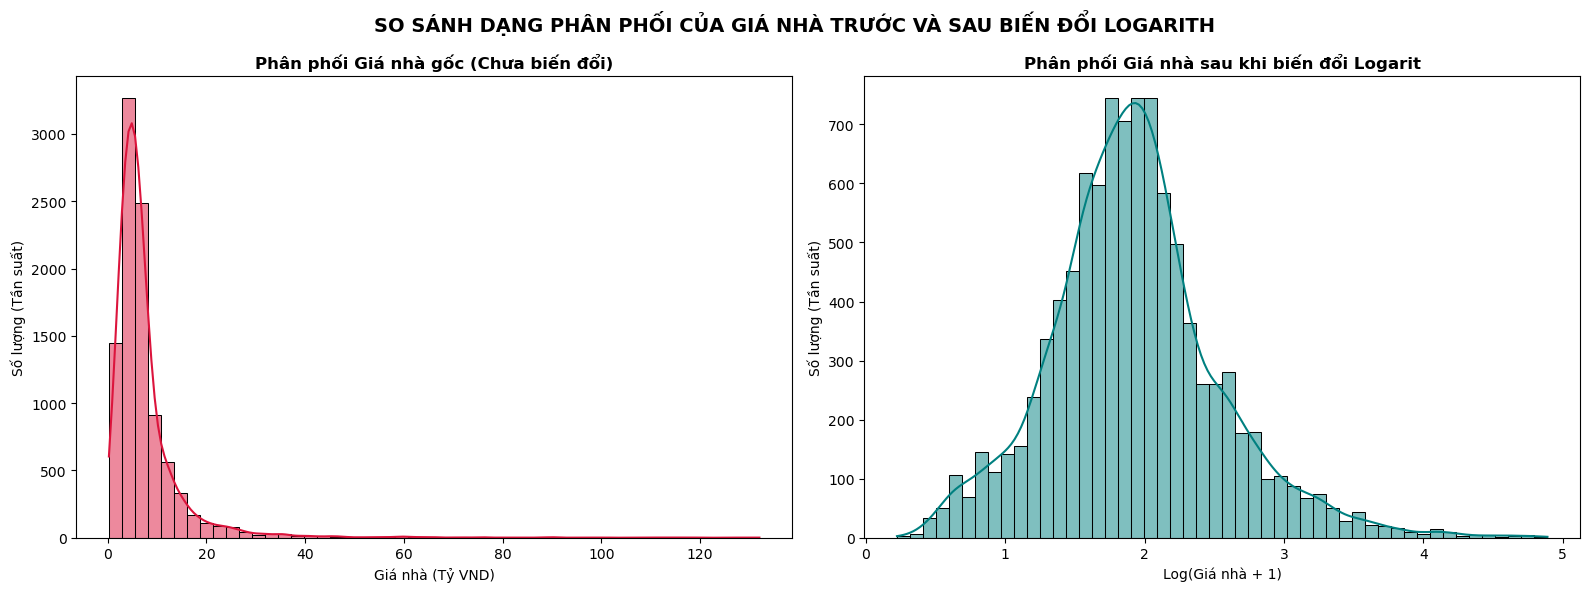

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ phân phối gốc 
sns.histplot(df_clean['price_billion'], kde=True, ax=axes[0], color='crimson', bins=50)
axes[0].set_title('Phân phối Giá nhà gốc (Chưa biến đổi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá nhà (Tỷ VND)')
axes[0].set_ylabel('Số lượng (Tần suất)')

# 2. Biểu đồ sau khi biến đổi Logarit (Dùng log1p để an toàn nếu có giá trị gần 0)
log_price = np.log1p(df_clean['price_billion'])
sns.histplot(log_price, kde=True, ax=axes[1], color='teal', bins=50)
axes[1].set_title('Phân phối Giá nhà sau khi biến đổi Logarit', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(Giá nhà + 1)')
axes[1].set_ylabel('Số lượng (Tần suất)')

# Tối ưu khoảng cách và hiển thị
plt.suptitle('SO SÁNH DẠNG PHÂN PHỐI CỦA GIÁ NHÀ TRƯỚC VÀ SAU BIẾN ĐỔI LOGARITH', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Dữ liệu bị lệch nhiều nên bây giờ chuyển sang dạng logarit 

In [193]:
# Cuyển giá nhà sang dạng logarit 
df_model = df_linear_encoded.copy()

df_model['log_price'] = np.log1p(df_model['price_billion'])

X = df_model.drop(columns=['price_billion', 'price_per_m2', 'log_price'])
y = df_model['log_price']

In [194]:
df_model.info()
column = ['price_per_m2']
df_model.drop(columns=column, errors='ignore')

<class 'pandas.DataFrame'>
Index: 8950 entries, 119 to 9761
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   bedroom                                  8950 non-null   int64  
 1   latitude                                 8950 non-null   float64
 2   longitude                                8950 non-null   float64
 3   area_m2                                  8950 non-null   float64
 4   price_per_m2                             8950 non-null   float64
 5   price_billion                            8950 non-null   float64
 6   Distance_to_center                       8950 non-null   float64
 7   district_norm_Binh_Tan                   8950 non-null   int64  
 8   district_norm_Binh_Thanh                 8950 non-null   int64  
 9   district_norm_Can_Gio                    8950 non-null   int64  
 10  district_norm_Cu_Chi                     8950 non-null   int64

,bedroom,latitude,longitude,area_m2,price_billion,Distance_to_center,district_norm_Binh_Tan,district_norm_Binh_Thanh,district_norm_Can_Gio,district_norm_Cu_Chi,...,category_Nhà ở,"category_Văn phòng, Mặt bằng kinh doanh",category_Đất,legal_status_norm_2_0,legal_status_norm_3_0,legal_status_norm_4_0,legal_status_norm_5_0,legal_status_norm_6_0,legal_status_norm_Unknown,log_price
119,2,10.686840,106.585480,59.0,2.690,16.074791,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.305626
157,1,10.667287,106.590070,65.0,1.200,17.149134,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0.788457
178,1,10.714312,106.651340,16.0,0.599,8.782399,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0.469378
179,3,10.666245,106.658610,140.0,4.200,13.101534,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.648659
204,4,10.699531,106.646810,90.0,4.200,10.400375,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.648659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9725,2,10.840954,106.797190,95.0,5.050,12.726847,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1.800058
9736,2,10.844955,106.786470,51.0,4.800,12.053572,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.757858
9738,2,10.890938,106.828316,76.0,1.450,18.856421,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0.896088
9743,2,10.806134,106.821300,190.0,13.800,13.557647,0,0,0,0,...,1,0,0,0,0,0,0,0,1,2.694627


In [195]:
# Chia lại dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [196]:
print("NaN trong X_train:", X_train.isna().sum().sum())
print("NaN trong X_test:", X_test.isna().sum().sum())
print("NaN trong y_train:", y_train.isna().sum())
print("NaN trong y_test:", y_test.isna().sum())

NaN trong X_train: 0
NaN trong X_test: 0
NaN trong y_train: 0
NaN trong y_test: 0


In [197]:
lr = LinearRegression()
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train,y_train)
print("Đang huấn luyện mô hình Linear Regression...")
rf.fit(X_train,y_train)
print("Đang huấn luyện mô hình Random Forest...")
print("Huấn luyện thành công")

Đang huấn luyện mô hình Linear Regression...
Đang huấn luyện mô hình Random Forest...
Huấn luyện thành công


In [198]:
# 1. Dự báo trên tập Test
y_pred_lr_2 = lr.predict(X_test)
y_pred_rf_2 = rf.predict(X_test)

# 2. Chuyển từ log về giá thực tế (tỷ đồng)
y_test_real = np.expm1(y_test)

y_pred_lr_real = np.expm1(y_pred_lr_2)
y_pred_rf_real = np.expm1(y_pred_rf_2)

# 3. Đánh giá Linear Regression
r2_lr = r2_score(y_test_real, y_pred_lr_real)
mae_lr = mean_absolute_error(y_test_real, y_pred_lr_real)
rmse_lr = np.sqrt(mean_squared_error(y_test_real, y_pred_lr_real))

# 4. Đánh giá Random Forest
r2_rf = r2_score(y_test_real, y_pred_rf_real)
mae_rf = mean_absolute_error(y_test_real, y_pred_rf_real)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_rf_real))

# 5. Bảng tổng hợp
evaluation_results = pd.DataFrame({
    'Chỉ số đánh giá': ['R² Score (%)', 'MAE (Tỷ đồng)','RMSE (Tỷ đồng)'],
    'Linear Regression': [ f"{r2_lr*100:.2f}%", f"{mae_lr:.3f}", f"{rmse_lr:.3f}"],
    'Random Forest': [f"{r2_rf*100:.2f}%",f"{mae_rf:.3f}",f"{rmse_rf:.3f}"]
})

print("BẢNG KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH Lần thứ 2")
display(evaluation_results)

BẢNG KẾT QUẢ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH Lần thứ 2


,Chỉ số đánh giá,Linear Regression,Random Forest
0,R² Score (%),38.01%,72.94%
1,MAE (Tỷ đồng),1.660,1.147
2,RMSE (Tỷ đồng),2.693,1.779


In [199]:
# Chuyển từ log về giá thực tế
y_test_real = np.expm1(y_test)
y_pred_lr_real = np.expm1(y_pred_lr_2)
y_pred_rf_real = np.expm1(y_pred_rf_2)


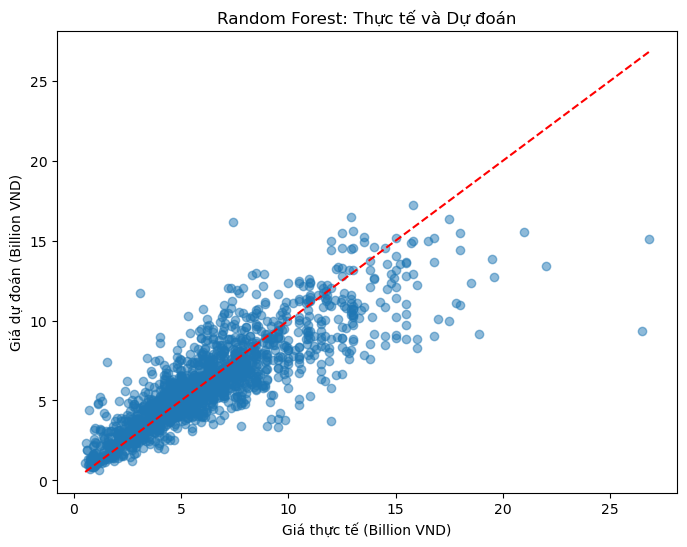

In [200]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_pred_rf_real, alpha=0.5)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--'
)
plt.xlabel("Giá thực tế (Billion VND)")
plt.ylabel("Giá dự đoán (Billion VND)")
plt.title("Random Forest: Thực tế và Dự đoán")
plt.show()

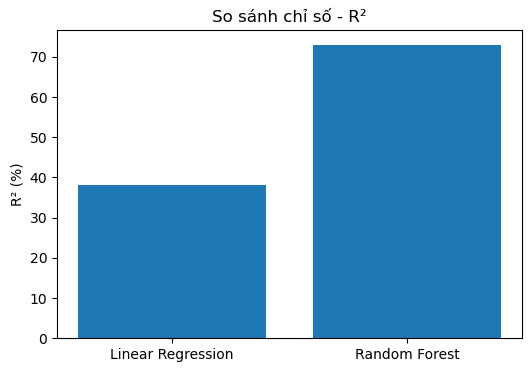

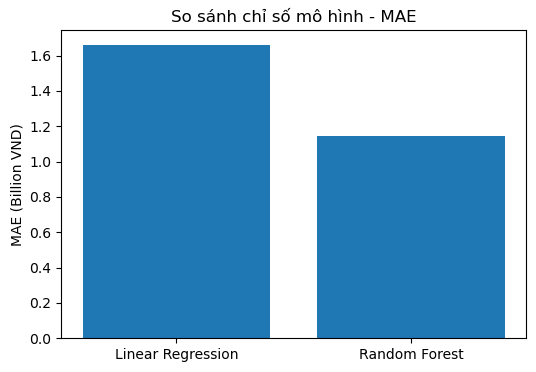

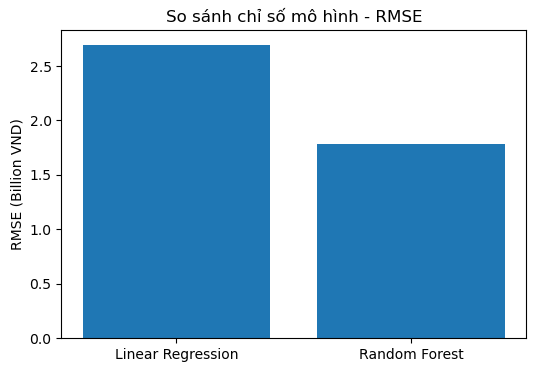

In [201]:
# Biểu đồ so sánh các chỉ số mô hình
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'R2':[r2_lr*100,r2_rf*100],
    'MAE':[mae_lr,mae_rf],
    'RMSE':[rmse_lr,rmse_rf]
})
comparison
plt.figure(figsize=(6,4))
plt.bar( comparison['Model'], comparison['R2'])
plt.ylabel("R² (%)")
plt.title("So sánh chỉ số - R²")
plt.show()
plt.figure(figsize=(6,4))
plt.bar( comparison['Model'], comparison['MAE'])
plt.ylabel("MAE (Billion VND)")
plt.title("So sánh chỉ số mô hình - MAE")
plt.show()
plt.figure(figsize=(6,4))
plt.bar( comparison['Model'], comparison['RMSE'])
plt.ylabel("RMSE (Billion VND)")
plt.title("So sánh chỉ số mô hình - RMSE")
plt.show()

In [202]:
# Các đặc trưng quan trọng của mô hình
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance.head(15)

,Feature,Importance
3,area_m2,0.249771
0,bedroom,0.237772
4,Distance_to_center,0.196771
2,longitude,0.066457
1,latitude,0.066199
36,legal_status_norm_5_0,0.066087
27,house_type_3.0,0.025824
37,legal_status_norm_6_0,0.017668
29,house_type_Unknown,0.015957
30,category_Nhà ở,0.007805


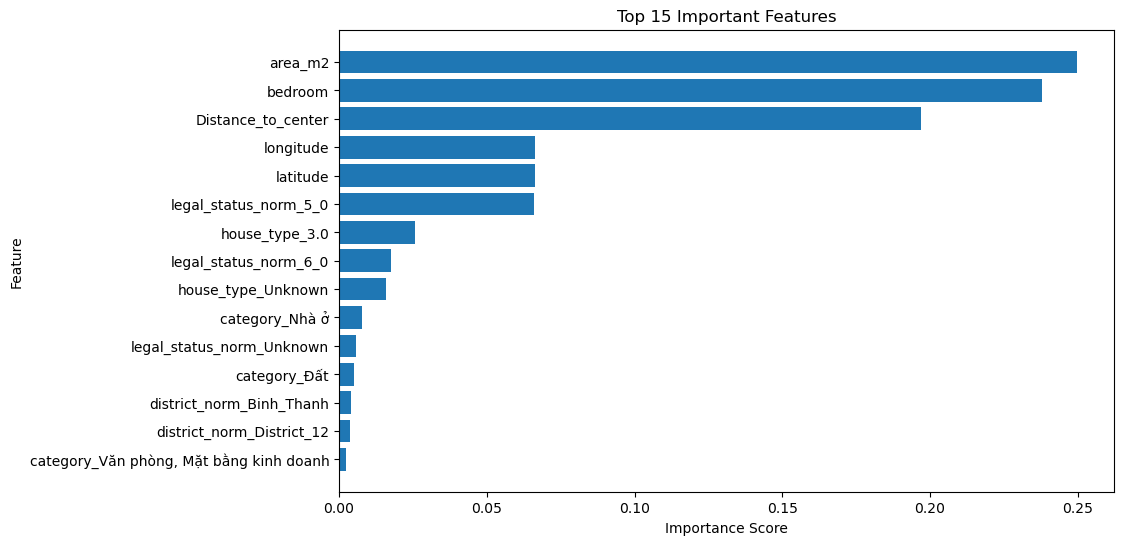

In [203]:
top15 = importance.head(15)
plt.figure(figsize=(10,6))
plt.barh(top15['Feature'],top15['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.show()

In [204]:
# Xác thực chéo
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)
print("Fold Scores:")
print(scores)
print("\nMean R²:")
print(scores.mean())
print("\nStd:")
print(scores.std())

Fold Scores:
[0.65213865 0.64198167 0.65516283 0.68790173 0.62780673]

Mean R²:
0.6529983217141384

Std:
0.01989801397450495


In [205]:
# Kết luận
final_result = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'R² (%)':[r2_lr*100,r2_rf*100],
    'MAE (Tỷ)':[mae_lr,mae_rf],
    'RMSE (Tỷ)':[rmse_lr,rmse_rf]
})

display(final_result)

,Model,R² (%),MAE (Tỷ),RMSE (Tỷ)
0,Linear Regression,38.006903,1.660213,2.693336
1,Random Forest,72.943442,1.147314,1.779325
